In [1]:
import pandas as pd

# ---- Load prior ----
df_prior = pd.read_csv("prior_samples_delta43.csv")

# ---- Load posteriors ----
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")
postALL = pd.read_csv("posterior_samples_All_3.csv")

print("Prior shape:", df_prior.shape)
print("Δ21 posterior shape:", post21.shape)
print("Δ43 posterior shape:", post43.shape)
print("ALL Δ posterior shape:", postALL.shape)

print("\nColumn names:")
print("Prior:", df_prior.columns.tolist())
print("Δ21 :", post21.columns.tolist())
print("Δ43 :", post43.columns.tolist())
print("ALL :", postALL.columns.tolist())


Prior shape: (2000, 7)
Δ21 posterior shape: (3000, 7)
Δ43 posterior shape: (3000, 7)
ALL Δ posterior shape: (3000, 11)

Column names:
Prior: ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b43', 's43']
Δ21 : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b21', 's21']
Δ43 : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b43', 's43']
ALL : ['x1', 'x2', 'x3', 'x4', 'log_x3', 'b21', 'b32', 'b43', 's21', 's32', 's43']


In [3]:
import pandas as pd

# ---- Load prior ----
df_prior = pd.read_csv("prior_samples_delta43.csv")

# ---- Load posteriors ----
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")
postALL = pd.read_csv("posterior_samples_All_3.csv")

# -----------------------------
# Helper: compute mean + std
# -----------------------------
def summarize(df):
    return df.describe().T[['mean', 'std']]

# ---- Create separate summaries ----
sum_prior = summarize(df_prior)
sum_21    = summarize(post21)
sum_43    = summarize(post43)
sum_all   = summarize(postALL)

# ---- Print each one separately ----
print("\n===== PRIOR summary =====")
print(sum_prior)

print("\n===== Δ21 POSTERIOR summary =====")
print(sum_21)

print("\n===== Δ43 POSTERIOR summary =====")
print(sum_43)

print("\n===== ALL Δ POSTERIOR summary =====")
print(sum_all)



===== PRIOR summary =====
               mean         std
x1         0.400121    0.101637
x2      4997.605003  984.290186
x3         2.245790   10.342943
x4         9.207227    0.590178
log_x3    -0.988079    1.941283
b43        0.007386    1.014503
s43        1.206994    0.910460

===== Δ21 POSTERIOR summary =====
               mean          std
x1         0.619273     0.020494
x2      5364.842447  1126.645872
x3         1.941681     4.969511
x4        10.305755     0.335564
log_x3    -0.971748     1.956616
b21        0.012073     1.000534
s21        5.255862     0.699251

===== Δ43 POSTERIOR summary =====
               mean          std
x1         0.599222     0.027490
x2      5475.992342  1026.049839
x3         2.408201     6.107729
x4        10.266633     0.240547
log_x3    -0.877126     2.013449
b43        0.007107     1.005974
s43        3.907759     0.665073

===== ALL Δ POSTERIOR summary =====
               mean         std
x1         0.645921    0.009097
x2      4280.51792

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

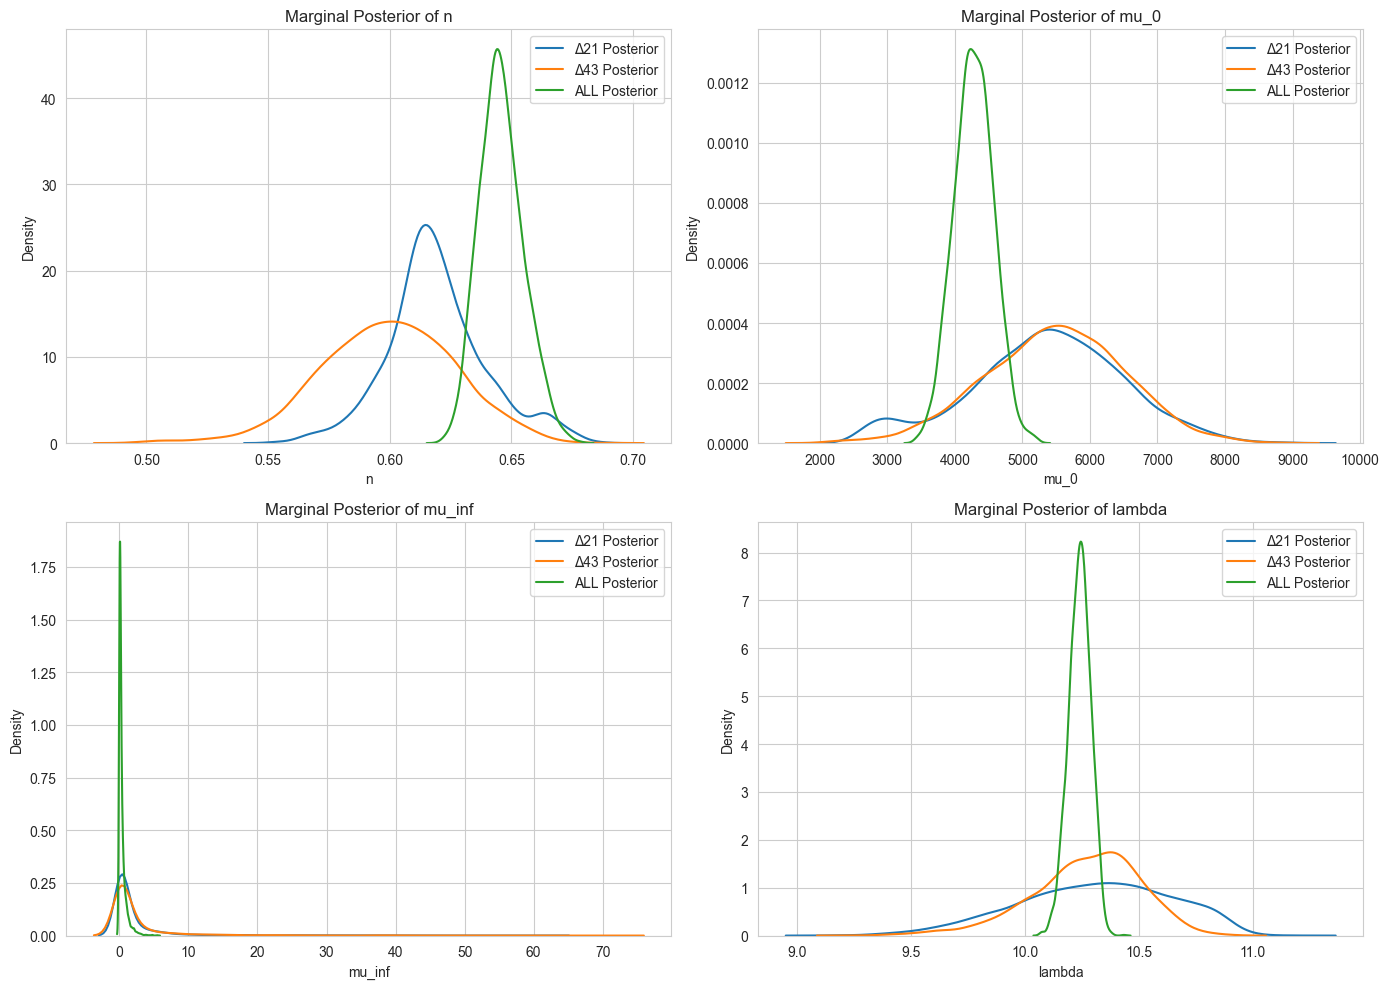

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load tables
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")
postALL = pd.read_csv("posterior_samples_All_3.csv")

# Rename columns for readability
rename_map = {
    "x1": "n",
    "x2": "mu_0",
    "x3": "mu_inf",
    "x4": "lambda"
}

post21 = post21.rename(columns=rename_map)
post43 = post43.rename(columns=rename_map)
postALL = postALL.rename(columns=rename_map)

# Bundle them into a dict for easy looping
posteriors = {
    "Δ21 Posterior": post21,
    "Δ43 Posterior": post43,
    "ALL Posterior": postALL
}

# Plot marginal posteriors
params = ["n", "mu_0", "mu_inf", "lambda"]

sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

for i, param in enumerate(params, 1):
    plt.subplot(2, 2, i)
    for name, df in posteriors.items():
        sns.kdeplot(df[param], label=name, fill=False)
    plt.title(f"Marginal Posterior of {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()


Using parameter columns: ['n', 'mu_0', 'mu_inf', 'lambda']


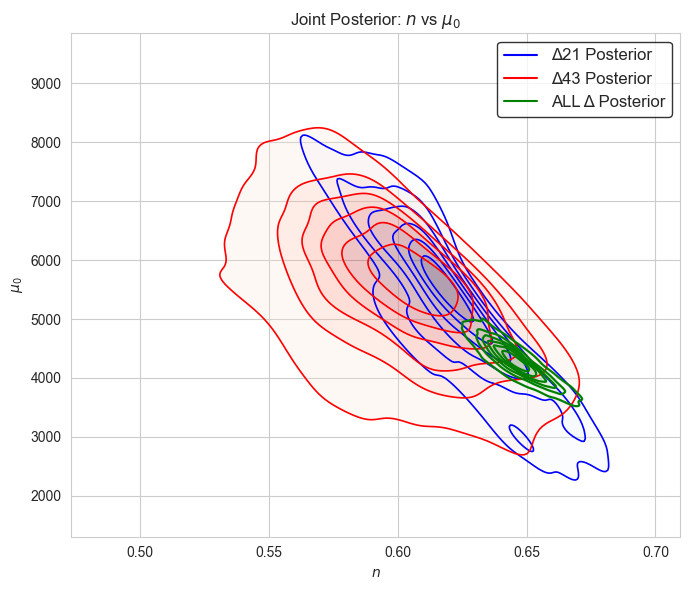

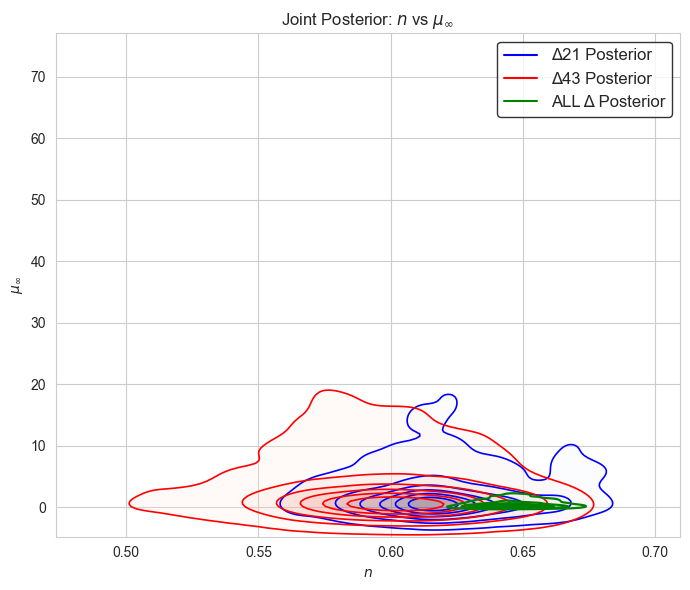

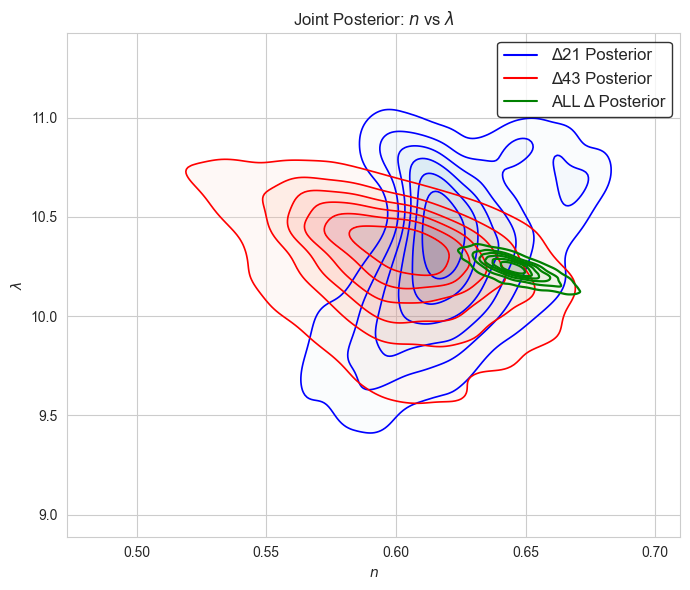

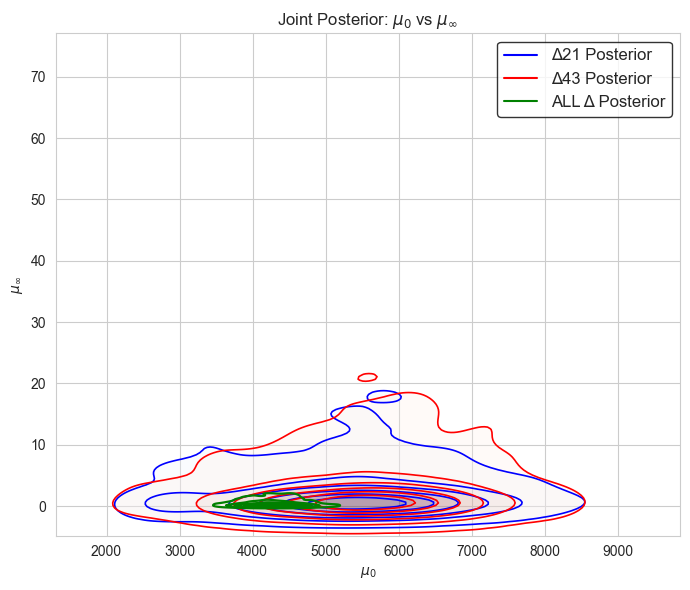

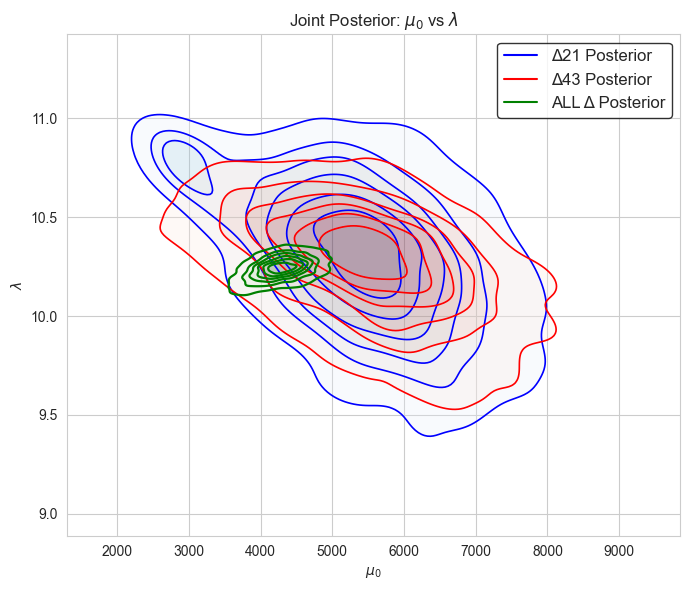

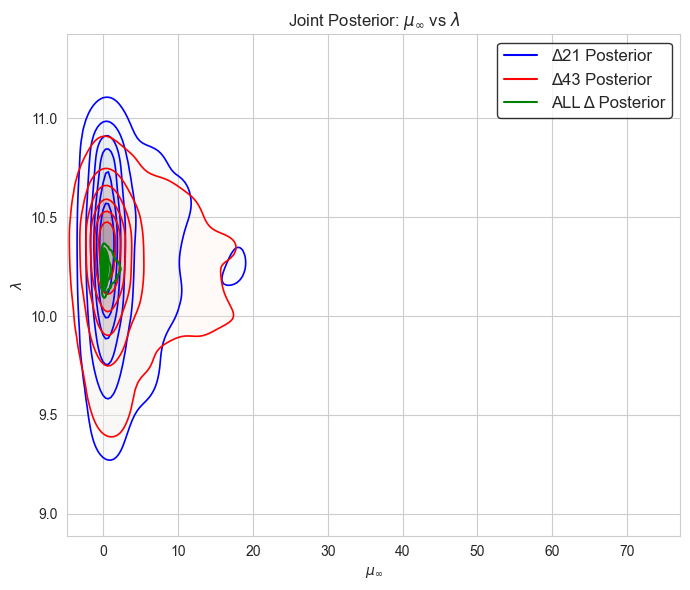

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings

# Suppress warnings from seaborn/matplotlib
warnings.filterwarnings("ignore")

# -----------------------------------
# 1. Detect parameter column names
# -----------------------------------
candidates_raw   = ["x1", "x2", "x3", "x4"]
candidates_named = ["n", "mu_0", "mu_inf", "lambda"]

cols = set(post21.columns) & set(post43.columns) & set(postALL.columns)

if all(c in cols for c in candidates_raw):
    param_cols = candidates_raw
    name_map = {
        "x1": r"$n$",
        "x2": r"$\mu_0$",
        "x3": r"$\mu_{\infty}$",
        "x4": r"$\lambda$",
    }
elif all(c in cols for c in candidates_named):
    param_cols = candidates_named
    name_map = {
        "n": r"$n$",
        "mu_0": r"$\mu_0$",
        "mu_inf": r"$\mu_{\infty}$",
        "lambda": r"$\lambda$",
    }
else:
    raise ValueError(
        f"Could not find expected parameter columns in dataframes. "
        f"Common columns are: {cols}"
    )

print("Using parameter columns:", param_cols)

# -----------------------------------
# 2. Create all unique variable pairs
# -----------------------------------
pairs = list(combinations(param_cols, 2))

sns.set_style("whitegrid")

# -----------------------------------
# 3. Plot each pair individually
# -----------------------------------
for (px, py) in pairs:

    plt.figure(figsize=(7, 6))

    # Δ21 (blue)
    sns.kdeplot(
        x=post21[px], y=post21[py],
        cmap="Blues", levels=7, fill=True, alpha=0.25, thresh=0.05
    )
    sns.kdeplot(
        x=post21[px], y=post21[py],
        color="blue", levels=7, fill=False, linewidths=1.2,
        label="Δ21 Posterior"
    )

    # Δ43 (red)
    sns.kdeplot(
        x=post43[px], y=post43[py],
        cmap="Reds", levels=7, fill=True, alpha=0.25, thresh=0.05
    )
    sns.kdeplot(
        x=post43[px], y=post43[py],
        color="red", levels=7, fill=False, linewidths=1.2,
        label="Δ43 Posterior"
    )

    # ALL Δ (green)
    sns.kdeplot(
        x=postALL[px], y=postALL[py],
        cmap="Greens", levels=7, fill=True, alpha=0.20, thresh=0.05
    )
    sns.kdeplot(
        x=postALL[px], y=postALL[py],
        color="green", levels=7, fill=False, linewidths=1.6,
        label="ALL Δ Posterior"
    )

    # ---------- Labels, title, legend (inside loop!) ----------
    plt.xlabel(name_map[px])
    plt.ylabel(name_map[py])
    plt.title(f"Joint Posterior: {name_map[px]} vs {name_map[py]}")

    legend_elements = [
        plt.Line2D([0], [0], color="blue",  label="Δ21 Posterior"),
        plt.Line2D([0], [0], color="red",   label="Δ43 Posterior"),
        plt.Line2D([0], [0], color="green", label="ALL Δ Posterior"),
    ]

    leg = plt.legend(
        handles=legend_elements,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fontsize=12
    )
    leg.set_zorder(10)

    plt.tight_layout()
    plt.show()
